# Smart Product Cataloger - Assignment

[View on Google Colab](https://colab.research.google.com/drive/1fplzzeYAi-bo1oRrwC2hGnVN_OlbQysR?usp=sharing)

Week 8: Multimodal AI for E-commerce Product Analysis

OBJECTIVE: Build an AI system that can automatically analyze product images
and generate metadata for e-commerce listings using CLIP and BLIP models.

LEARNING GOALS:
- Use CLIP for zero-shot image classification
- Use BLIP for image captioning and visual question answering
- Combine multiple AI models for practical applications
- Build a complete product analysis pipeline

---

### Import the necessary libraries

In [2]:
import torch
from transformers import (
    CLIPProcessor, CLIPModel,
    BlipProcessor, BlipForConditionalGeneration, BlipForQuestionAnswering, BlipForImageTextRetrieval,
    pipeline
)
from PIL import Image
import requests
import numpy as np
from typing import Dict, List, Union

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

In [70]:
# Additions
import matplotlib.pyplot as plt
from google.colab import userdata

### Define Global Variables for Models and Processors

In [3]:
# Global variables to store models (we'll load them once)
clip_model = None
clip_processor = None
blip_caption_model = None
blip_caption_processor = None
blip_vqa_model = None
blip_vqa_processor = None

### Additional handy variables to test various models

In [4]:
clip_model_name = "openai/clip-vit-base-patch32"
blip_caption_model_name = "Salesforce/blip-image-captioning-base"
blip_vqa_model_name = "Salesforce/blip-vqa-base"

### Load the Models from HuggingFace

In [49]:
def load_models():
    """
    Load all required models for product analysis

    TODO: Load the following models and store them in global variables:
    1. CLIP model for image classification
    2. BLIP model for image captioning
    3. BLIP model for visual question answering

    MODELS TO LOAD:
    - CLIP: "openai/clip-vit-base-patch32"
    - BLIP Caption: "Salesforce/blip-image-captioning-base"
    - BLIP VQA: "Salesforce/blip-vqa-base"

    HINT: Use the model loading patterns from Week8/session_2 notebooks
    HINT: Use 'global' keyword to modify global variables

    EXAMPLE:
    global clip_model, clip_processor
    clip_model = ?
    clip_processor = ?
    """
    global clip_model, clip_processor, blip_caption_model, blip_caption_processor, blip_vqa_model, blip_vqa_processor

    print("🚀 Loading models for Smart Product Cataloger...")

    # TODO: Load CLIP model and processor
    print(f"Loading CLIP model: {clip_model_name}")
    clip_model = CLIPModel.from_pretrained(clip_model_name)
    clip_processor = CLIPProcessor.from_pretrained(clip_model_name)
    clip_model.eval()
    print(f"CLIP Model loaded successfully!")
    #print(f"Vision config: {clip_model.config.vision_config}")
    #print(f"Text config: {clip_model.config.text_config}")

    # TODO: Load BLIP caption model and processor
    task = "captioning" # hardcoding task
    print(f"Loading BLIP model: {blip_caption_model_name}")
    blip_caption_processor = BlipProcessor.from_pretrained(blip_caption_model_name)
    blip_caption_model = BlipForConditionalGeneration.from_pretrained(blip_caption_model_name)
    blip_caption_model.eval()
    print(f"BLIP Model loaded successfully!")
    #print(f"Model config: {blip_caption_model.config}")

    # TODO: Load BLIP VQA model and processor
    print(f"Loading BLIP VQA model: {blip_vqa_model_name}")
    blip_vqa_model = BlipForQuestionAnswering.from_pretrained(blip_vqa_model_name)
    blip_vqa_processor = BlipProcessor.from_pretrained(blip_vqa_model_name)
    blip_vqa_model.eval()
    print("VQA model loaded successfully!")
    #print(f"Model config: {blip_vqa_model.config}")

    # DUMMY IMPLEMENTATION (Remove this when implementing)
    #print("⚠️ DUMMY: Models not loaded yet - implement the TODO sections above")

    print("✅ All models loaded successfully!")

# TEST: Load models
print("🔧 TESTING: Loading models...")
load_models()
print()

🔧 TESTING: Loading models...
🚀 Loading models for Smart Product Cataloger...
Loading CLIP model: openai/clip-vit-base-patch32
CLIP Model loaded successfully!
Loading BLIP model: Salesforce/blip-image-captioning-base
BLIP Model loaded successfully!
Loading BLIP VQA model: Salesforce/blip-vqa-base
VQA model loaded successfully!
✅ All models loaded successfully!



---

### Load Image from URL
  
You can extend this function to load an image from a path on your local system and apply the required transforms to it.

In [6]:
def load_image_from_url(url: str) -> Image.Image:
    """
    Load an image from a URL

    Args:
        url (str): URL of the image to load

    Returns:
        Image.Image: PIL Image object or None if failed

    TODO: Implement image loading from URL
    HINT: Use requests.get() and Image.open()

    EXAMPLE INPUT: "https://images.unsplash.com/photo-1542291026-7eec264c27ff"
    EXAMPLE OUTPUT: PIL Image object of Nike shoes
    """

    # TODO: Implement image loading
    # 1. Use requests.get() to fetch the image
    # 2. Use Image.open() to create PIL Image
    # 3. Convert to RGB format
    # 4. Handle errors gracefully

    # DUMMY IMPLEMENTATION (Remove this when implementing)
    #print(f"⚠️ DUMMY: Would load image from {url}")

    print(f"⚠️ Loading image from {url}")

    try:
        response = requests.get(url, stream=True)
        response.raise_for_status()
        image = Image.open(response.raw)
        return image
    except Exception as e:
        print(f"Error loading image from URL: {e}")
        raise

# TEST: Load image
print("📸 TESTING: Loading image from URL...")
sample_url = "https://images.unsplash.com/photo-1542291026-7eec264c27ff"  # Nike shoes
image = load_image_from_url(sample_url)

print(f"Image loaded successfully: {image is not None}")
if image:
    print(f"Image size: {image.size}")
print()

📸 TESTING: Loading image from URL...
⚠️ Loading image from https://images.unsplash.com/photo-1542291026-7eec264c27ff
Image loaded successfully: True
Image size: (5472, 3648)



---

### Create Testing Dataset (5 Images) test_images

In [69]:
from dataclasses import dataclass, field
from typing import Optional

@dataclass
class TestImage:
    input_category: str
    url: str
    image: Optional[Image.Image] = field(default=None)
    classified_category: Optional[str] = field(default=None)
    second_best_category: Optional[str] = field(default=None)
    caption : Optional[str] = field(default=None)
    description : Optional[str] = field(default=None)
    attributes: Optional[Dict] = field(default_factory=dict)


test_images = [
    TestImage(input_category="clothing", url="https://tse3.mm.bing.net/th?id=OIP.Y1ZCZNBuM6LyX9xNy3_jyAHaHa&pid=Api"),
    TestImage(input_category="shoes", url="https://tse1.mm.bing.net/th?id=OIP.q4gNcjltZtqufiyg0XL0cwHaE8&pid=Api"),
    TestImage(input_category="electronics", url="https://tse4.mm.bing.net/th?id=OIP.w18CXqXfi-8C-d1q89_ycgHaE8&pid=Api"),
    TestImage(input_category="furniture", url="https://tse2.mm.bing.net/th/id/OIP.ajRJhWSQygdDZ4lYhVvViAHaHa?pid=Api"),
    TestImage(input_category="books", url="https://tse2.mm.bing.net/th?id=OIP.jI3l55g0qfpmktGJiBmZ5wHaE8&pid=Api"),
    TestImage(input_category="toys", url="https://tse1.mm.bing.net/th/id/OIP.yhbFumPhqRwbTaKsIBd90AHaEK?pid=Api"),
]

# Example usage
for item in test_images:
    print(f"{item.input_category}: {item.url}")

clothing: https://tse3.mm.bing.net/th?id=OIP.Y1ZCZNBuM6LyX9xNy3_jyAHaHa&pid=Api
shoes: https://tse1.mm.bing.net/th?id=OIP.q4gNcjltZtqufiyg0XL0cwHaE8&pid=Api
electronics: https://tse4.mm.bing.net/th?id=OIP.w18CXqXfi-8C-d1q89_ycgHaE8&pid=Api
furniture: https://tse2.mm.bing.net/th/id/OIP.ajRJhWSQygdDZ4lYhVvViAHaHa?pid=Api
books: https://tse2.mm.bing.net/th?id=OIP.jI3l55g0qfpmktGJiBmZ5wHaE8&pid=Api
toys: https://tse1.mm.bing.net/th/id/OIP.yhbFumPhqRwbTaKsIBd90AHaEK?pid=Api


### Product Classification using CLIP

In [10]:
from PIL import Image
from typing import List, Dict

In [ ]:
def classify_product_image(image: Image.Image, candidate_labels: List[str]) -> List[Dict]:
    """
    Classify image using CLIP zero-shot classification

    Args:
        image (Image.Image): PIL Image to classify
        candidate_labels (List[str]): List of possible categories

    Returns:
        List[Dict]: Classification results with labels and scores

    TODO: Implement zero-shot classification using CLIP
    HINT: Use the pipeline approach from clip.ipynb

    EXAMPLE INPUT:
        image = <PIL Image of shoes>
        candidate_labels = ["clothing", "shoes", "electronics", "furniture"]

    EXAMPLE OUTPUT:
        [
            {"label": "shoes", "score": 0.8945},
            {"label": "clothing", "score": 0.0823},
            {"label": "electronics", "score": 0.0156},
            {"label": "furniture", "score": 0.0076}
        ]
    """
    print("🔍 Classifying product category...")

    # TODO: Implement CLIP classification
    # 1. Create a zero-shot-image-classification pipeline
    # clip_pipeline = ?

    # 2. Use the pipeline to classify the image
    # results = ?

    # 3. Return the results
    # return results

    # Create pipeline
    clip_pipeline = pipeline(
        task="zero-shot-image-classification",
        model=clip_model_name, # loading from global variable
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
        device=0 if torch.cuda.is_available() else -1
    )

    # Perform classification
    results = clip_pipeline(image, candidate_labels=candidate_labels)

    #print("Classification Results:")
    #for result in results:
    #    print(f"  {result['label']}: {result['score']:.4f}")

    return results


    # DUMMY IMPLEMENTATION (Remove this when implementing)
    '''
    dummy_results = [
        {"label": candidate_labels[0], "score": 0.8945},
        {"label": candidate_labels[1], "score": 0.0823},
    ]
    print("⚠️ DUMMY: Returning fake classification results")

    return dummy_results
    '''

#for result in classification_results:
#    print(f"  {result['label']}: {result['score']:.4f}")

---

In [58]:
# TEST: Classify image
print("🔍 TESTING: Classifying product image...")
image = load_image_from_url("https://images.unsplash.com/photo-1542291026-7eec264c27ff")
categories = ["clothing", "shoes", "electronics", "furniture", "books", "toys"]
classification_results = classify_product_image(image, categories)
top_category = None

print("🔍 REAL USE CASE 5 images one per category: Classifying product image...")
#Building the result dataset
idx = 1
classified_images = test_images.copy()
for idx, item in enumerate(classified_images, start=1):
    print(f"Image#:{idx}: Input Cat: {item.input_category}: {item.url}")
    image = load_image_from_url(item.url)

    classification_results = classify_product_image(image, categories)
    #print("Classification Results:")
    #print("DEBUG -> classification_results[0]:", classification_results[0])

    top_category = classification_results[0]['label']
    item.classified_category = top_category or 'error'
    item.second_best_category = classification_results[1]['label'] if len(classification_results) > 1 else None
    print(f"Classification Result: {item.classified_category}")

# Printing output for review
# ANSI escape codes for coloring
GREEN = "\033[92m"
RED = "\033[91m"
RESET = "\033[0m"

print("SUMMARY for Classification Results:")
for item in classified_images:
    if item.input_category == item.classified_category:
        color = GREEN
        print(f"{item.input_category}: {color}{item.classified_category}{RESET}")
    else:
        color = RED
        sec_color = GREEN if item.second_best_category == item.input_category else RED
        print(f"{item.input_category}: {color}{item.classified_category}{RESET} Second Best: {sec_color}{item.second_best_category}{RESET}")

🔍 TESTING: Classifying product image...
⚠️ Loading image from https://images.unsplash.com/photo-1542291026-7eec264c27ff
🔍 Classifying product category...


Device set to use cuda:0


🔍 REAL USE CASE 5 images one per category: Classifying product image...
Image#:1: Input Cat: clothing: https://tse3.mm.bing.net/th?id=OIP.Y1ZCZNBuM6LyX9xNy3_jyAHaHa&pid=Api
⚠️ Loading image from https://tse3.mm.bing.net/th?id=OIP.Y1ZCZNBuM6LyX9xNy3_jyAHaHa&pid=Api
🔍 Classifying product category...


Device set to use cuda:0


Classification Result: shoes
Image#:2: Input Cat: shoes: https://tse1.mm.bing.net/th?id=OIP.q4gNcjltZtqufiyg0XL0cwHaE8&pid=Api
⚠️ Loading image from https://tse1.mm.bing.net/th?id=OIP.q4gNcjltZtqufiyg0XL0cwHaE8&pid=Api
🔍 Classifying product category...


...

Classification Result: furniture
Image#:5: Input Cat: books: https://tse2.mm.bing.net/th?id=OIP.jI3l55g0qfpmktGJiBmZ5wHaE8&pid=Api
⚠️ Loading image from https://tse2.mm.bing.net/th?id=OIP.jI3l55g0qfpmktGJiBmZ5wHaE8&pid=Api
🔍 Classifying product category...


Device set to use cuda:0


Classification Result: books
Image#:6: Input Cat: toys: https://tse1.mm.bing.net/th/id/OIP.yhbFumPhqRwbTaKsIBd90AHaEK?pid=Api
⚠️ Loading image from https://tse1.mm.bing.net/th/id/OIP.yhbFumPhqRwbTaKsIBd90AHaEK?pid=Api
🔍 Classifying product category...


Device set to use cuda:0


Classification Result: toys
SUMMARY for Classification Results:
clothing: shoes Second Best: clothing
shoes: shoes
electronics: electronics
furniture: furniture
books: books
toys: toys


### Generate Product Caption

In [59]:
def generate_product_caption(image: Image.Image) -> str:
    """
    Generate a descriptive caption for the image using BLIP

    Args:
        image (Image.Image): PIL Image to caption

    Returns:
        str: Generated caption describing the image

    TODO: Implement image captioning using BLIP
    HINT: Use the captioning approach from blip.ipynb
    HINT: Use the global blip_caption_model and blip_caption_processor

    EXAMPLE INPUT: <PIL Image of red Nike sneakers>
    EXAMPLE OUTPUT: "a pair of red nike sneakers on a white background"
    """
    print("📝 Generating image caption...")

    max_length = 50 # max tokens
    num_beams = 5 # num_beams=5 will consider the 5 most likely continuations at each step.

    # TODO: Implement BLIP captioning
    # 1. Process the image using blip_caption_processor
    # inputs = ?
    inputs = blip_caption_processor(image, return_tensors="pt")
    #print(inputs)
    print(f"DEBUG: Processing Image: {inputs['pixel_values'].shape} (batch size, channels, height, width)")
    # 2. Generate caption using blip_caption_model
    # with torch.no_grad():
    #     out = ?
    # Generate caption
    # Beam Search (beam width >1) is a smart way of generating text from a model like BLIP, by keeping multiple best options at each step rather than just the most likely one (as Greedy Search does).
    with torch.no_grad():  # we skip gradients generation as we are not training, we save resources and speed up things
        out = blip_caption_model.generate(
            **inputs, # This unpacks the inputs dictionary — typically returned by a processor or tokenizer — and passes its values as arguments.
            max_length=max_length, # Sets the maximum length of the generated sequence (e.g., max 30 tokens in the caption)
            num_beams=num_beams, # Sets the beam width for beam search decoding:, 1 = greedy search (fastest, but lower quality), >1 = beam search (better quality, more expensive)
            early_stopping=True # Stops beam search as soon as all beams finish generating an end-of-sequence token (</s>), rather than continuing to max_length
        )

    # 3. Decode and return the caption
    # caption = ?
    # return caption

    # Decode caption
    caption = blip_caption_processor.decode(out[0], skip_special_tokens=True)

    #print(f"Generated Caption: '{caption}'")
    return caption

    # DUMMY IMPLEMENTATION (Remove this when implementing)
    #dummy_caption = "a product on a white background"
    #print(f"⚠️ DUMMY: Generated caption: '{dummy_caption}'")
    #return dummy_caption

# TEST: Generate caption
#print("📝 TESTING: Generating product caption...")
#caption = generate_product_caption(image)
#print(f"Generated Caption: '{caption}'")

In [60]:
def visualize_caption_result(image: Image.Image, caption: str, title: str = "BLIP Image Captioning", preview_size: int = 6):
    """
    Display image with generated caption.

    Args:
        image (PIL.Image): The input image
        caption (str): The generated caption
        title (str): Plot title
    """
    plt.figure(figsize=(preview_size, preview_size))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"{title}\n\nCaption: \"{caption}\"", fontsize=12, pad=20)
    plt.tight_layout()
    plt.show()



🔍 TESTING: Generating caption for image...
🔍 REAL USE CASE 5 images one per category: Captioning product image...
Image#:1: Input Cat: clothing: https://tse3.mm.bing.net/th?id=OIP.Y1ZCZNBuM6LyX9xNy3_jyAHaHa&pid=Api
⚠️ Loading image from https://tse3.mm.bing.net/th?id=OIP.Y1ZCZNBuM6LyX9xNy3_jyAHaHa&pid=Api
📝 Generating image caption...
DEBUG: Processing Image: torch.Size([1, 3, 384, 384]) (batch size, channels, height, width)
Caption: 'a pair of green and white sneakers with orange laces'


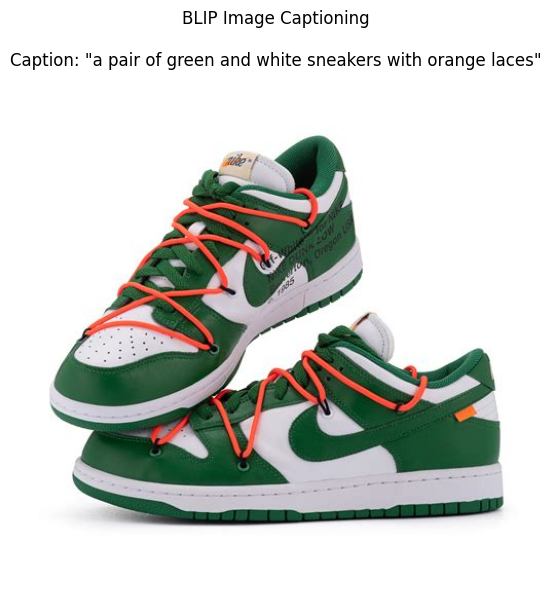

Image#:2: Input Cat: shoes: https://tse1.mm.bing.net/th?id=OIP.q4gNcjltZtqufiyg0XL0cwHaE8&pid=Api
⚠️ Loading image from https://tse1.mm.bing.net/th?id=OIP.q4gNcjltZtqufiyg0XL0cwHaE8&pid=Api
📝 Generating image caption...
DEBUG: Processing Image: torch.Size([1, 3, 384, 384]) (batch size, channels, height, width)
Caption: 'a pair of asics running shoes'


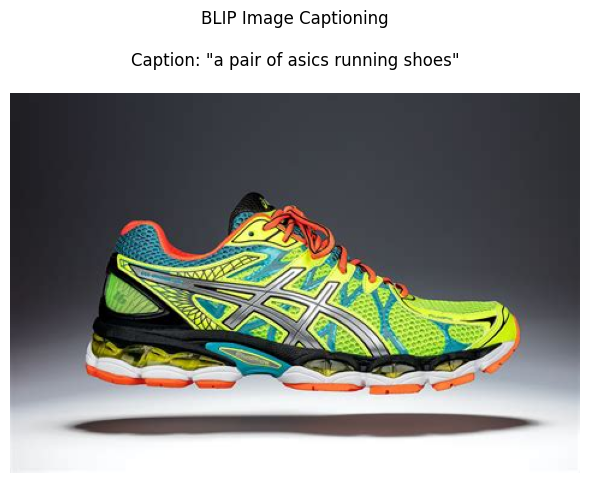

Image#:3: Input Cat: electronics: https://tse4.mm.bing.net/th?id=OIP.w18CXqXfi-8C-d1q89_ycgHaE8&pid=Api
⚠️ Loading image from https://tse4.mm.bing.net/th?id=OIP.w18CXqXfi-8C-d1q89_ycgHaE8&pid=Api
📝 Generating image caption...
DEBUG: Processing Image: torch.Size([1, 3, 384, 384]) (batch size, channels, height, width)
Caption: 'a blue background with various items on it'


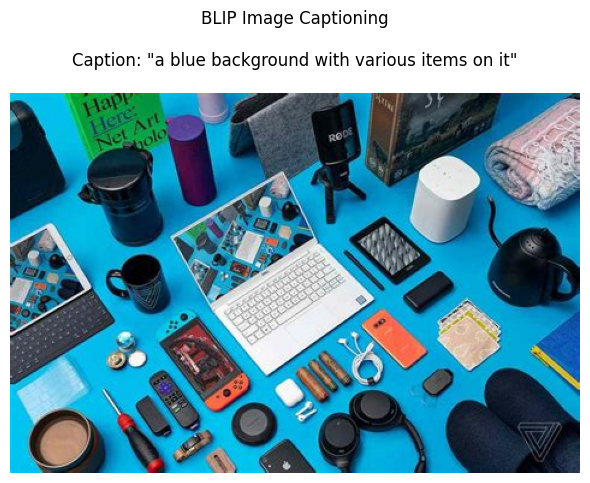

Image#:4: Input Cat: furniture: https://tse2.mm.bing.net/th/id/OIP.ajRJhWSQygdDZ4lYhVvViAHaHa?pid=Api
⚠️ Loading image from https://tse2.mm.bing.net/th/id/OIP.ajRJhWSQygdDZ4lYhVvViAHaHa?pid=Api
📝 Generating image caption...
DEBUG: Processing Image: torch.Size([1, 3, 384, 384]) (batch size, channels, height, width)
Caption: 'a living room with a couch and coffee table'


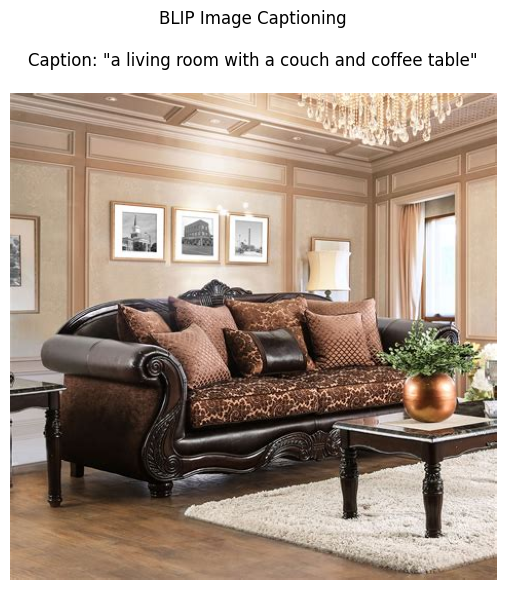

Image#:5: Input Cat: books: https://tse2.mm.bing.net/th?id=OIP.jI3l55g0qfpmktGJiBmZ5wHaE8&pid=Api
⚠️ Loading image from https://tse2.mm.bing.net/th?id=OIP.jI3l55g0qfpmktGJiBmZ5wHaE8&pid=Api
📝 Generating image caption...
DEBUG: Processing Image: torch.Size([1, 3, 384, 384]) (batch size, channels, height, width)
Caption: 'old books on a shelf'


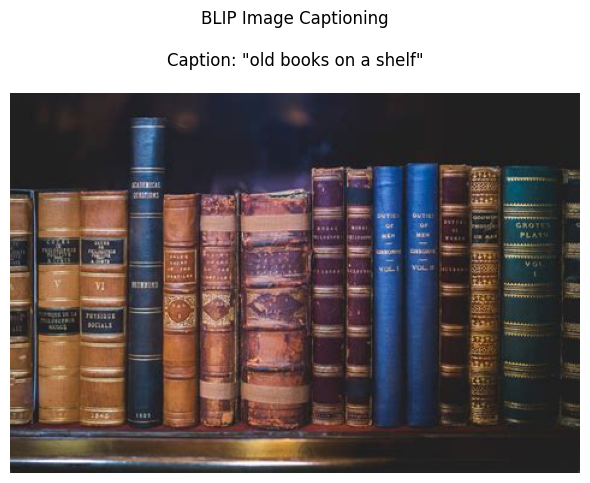

Image#:6: Input Cat: toys: https://tse1.mm.bing.net/th/id/OIP.yhbFumPhqRwbTaKsIBd90AHaEK?pid=Api
⚠️ Loading image from https://tse1.mm.bing.net/th/id/OIP.yhbFumPhqRwbTaKsIBd90AHaEK?pid=Api
📝 Generating image caption...
DEBUG: Processing Image: torch.Size([1, 3, 384, 384]) (batch size, channels, height, width)
Caption: 'a toy machine sitting on top of a table'


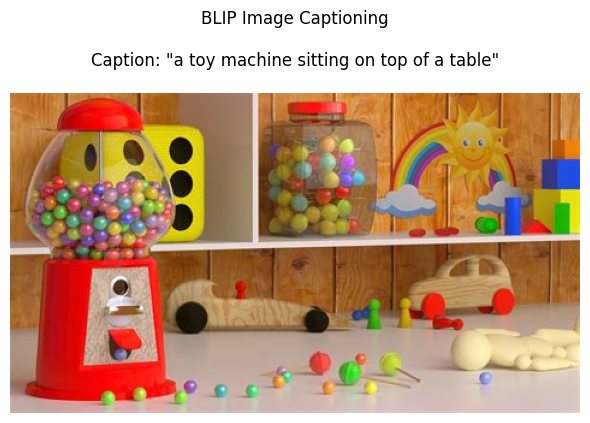

In [61]:
# TEST: Generate Product Caption
print("🔍 TESTING: Generating caption for image...")

print("🔍 REAL USE CASE 5 images one per category: Captioning product image...")
#Building the result dataset
idx = 1
captioned_images = test_images.copy()
for idx, item in enumerate(captioned_images, start=1):
    print(f"Image#:{idx}: Input Cat: {item.input_category}: {item.url}")
    image = load_image_from_url(item.url)
    caption = generate_product_caption(image)
    item.caption = caption
    print(f"Caption: '{caption}'")
    visualize_caption_result(image, caption)

    #classification_results = classify_product_image(image, categories)
    #top_category = classification_results[0]['label']
    #item.classified_category = top_category or 'error'
    #item.second_best_category = classification_results[1]['label'] if len(classification_results) > 1 else None
    #print(f"Classification Result: {item.classified_category}")


---

### Product Question and Answering

In [ ]:
def ask_about_product(image: Image.Image, question: str) -> str:
    """
    Answer questions about the image using BLIP VQA

    Args:
        image (Image.Image): PIL Image to analyze
        question (str): Question to ask about the image

    Returns:
        str: Answer to the question

    TODO: Implement visual question answering using BLIP VQA
    HINT: Use the VQA approach from blip.ipynb
    HINT: Use the global blip_vqa_model and blip_vqa_processor

    EXAMPLE INPUT:
        image = <PIL Image of red shoes>
        question = "What color are these shoes?"

    EXAMPLE OUTPUT: "red"
    """
    print(f"❓ Answering: '{question}'")

    max_length = 20
    num_beams= 5

    # TODO: Implement BLIP VQA
    # 1. Process image and question using blip_vqa_processor
    # inputs = ?
    # Process image and question
    inputs =  blip_vqa_processor(image, question, return_tensors="pt")

    # 2. Generate answer using blip_vqa_model
    # with torch.no_grad():
    #     out = ?
    with torch.no_grad():
        out = blip_vqa_model.generate(
            **inputs,
            max_length=max_length,
            num_beams=num_beams,
            early_stopping=True
        )

    # 3. Decode and return the answer
    # answer = ?
    # return answer

    # Decode answer
    answer = blip_vqa_processor.decode(out[0], skip_special_tokens=True)

    print(f"Answer: '{answer}'")
    return answer


    # DUMMY IMPLEMENTATION (Remove this when implementing)
    #dummy_answer = "unknown"
    #print(f"⚠️ DUMMY: Answer: {dummy_answer}")
    #return dummy_answer



❓ TESTING: Visual Question Answering...
🔍 REAL USE CASE 5 images one per category: QA product image...
Image#:1: Auto Cat:shoes: Desc a pair of green and white sneakers with orange laces
⚠️ Loading image from https://tse3.mm.bing.net/th?id=OIP.Y1ZCZNBuM6LyX9xNy3_jyAHaHa&pid=Api


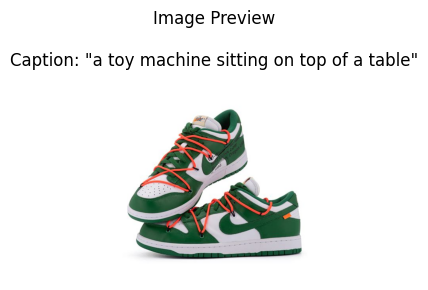

VQA Results:
❓ Answering: 'What color are these shoes?'
Answer: 'green and white'
  Q: What color are these shoes?
  A: green and white

❓ Answering: 'What brand are these shoes?'
Answer: 'nike'
  Q: What brand are these shoes?
  A: nike

❓ Answering: 'Are these sneakers or dress shoes?'
Answer: 'sneakers'
  Q: Are these sneakers or dress shoes?
  A: sneakers

Image#:2: Auto Cat:shoes: Desc a pair of asics running shoes
⚠️ Loading image from https://tse1.mm.bing.net/th?id=OIP.q4gNcjltZtqufiyg0XL0cwHaE8&pid=Api


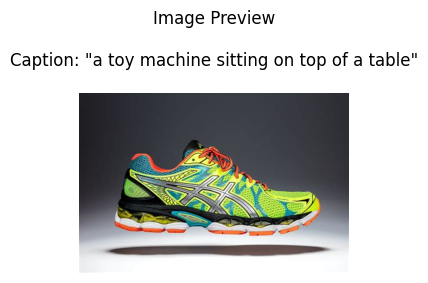

VQA Results:
❓ Answering: 'What color are these shoes?'
Answer: 'green'
  Q: What color are these shoes?
  A: green

❓ Answering: 'What brand are these shoes?'
Answer: 'asics'
  Q: What brand are these shoes?
  A: asics

❓ Answering: 'Are these sneakers or dress shoes?'
Answer: 'sneakers'
  Q: Are these sneakers or dress shoes?
  A: sneakers

Image#:3: Auto Cat:electronics: Desc a blue background with various items on it
⚠️ Loading image from https://tse4.mm.bing.net/th?id=OIP.w18CXqXfi-8C-d1q89_ycgHaE8&pid=Api


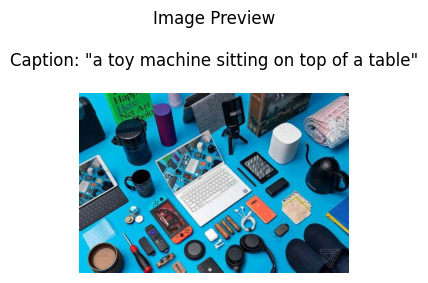

VQA Results:
❓ Answering: 'What color are these shoes?'
Answer: 'black'
  Q: What color are these shoes?
  A: black

❓ Answering: 'What brand are these shoes?'
Answer: 'nike'
  Q: What brand are these shoes?
  A: nike

❓ Answering: 'Are these sneakers or dress shoes?'
Answer: 'dress shoes'
  Q: Are these sneakers or dress shoes?
  A: dress shoes

Image#:4: Auto Cat:furniture: Desc a living room with a couch and coffee table
⚠️ Loading image from https://tse2.mm.bing.net/th/id/OIP.ajRJhWSQygdDZ4lYhVvViAHaHa?pid=Api


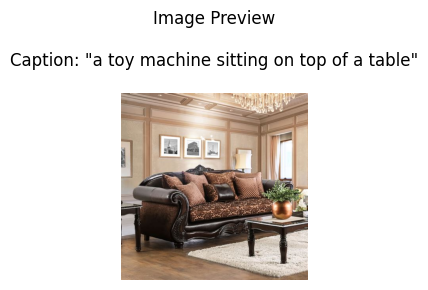

VQA Results:
❓ Answering: 'What color are these shoes?'
Answer: 'black'
  Q: What color are these shoes?
  A: black

❓ Answering: 'What brand are these shoes?'
Answer: 'no shoes'
  Q: What brand are these shoes?
  A: no shoes

❓ Answering: 'Are these sneakers or dress shoes?'
Answer: 'dress shoes'
  Q: Are these sneakers or dress shoes?
  A: dress shoes

Image#:5: Auto Cat:books: Desc old books on a shelf
⚠️ Loading image from https://tse2.mm.bing.net/th?id=OIP.jI3l55g0qfpmktGJiBmZ5wHaE8&pid=Api


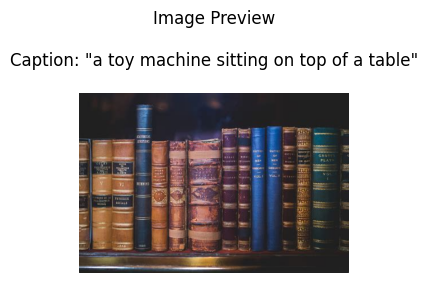

VQA Results:
❓ Answering: 'What color are these shoes?'
Answer: 'no shoes'
  Q: What color are these shoes?
  A: no shoes

❓ Answering: 'What brand are these shoes?'
Answer: 'no shoes'
  Q: What brand are these shoes?
  A: no shoes

❓ Answering: 'Are these sneakers or dress shoes?'
Answer: 'dress shoes'
  Q: Are these sneakers or dress shoes?
  A: dress shoes

Image#:6: Auto Cat:toys: Desc a toy machine sitting on top of a table
⚠️ Loading image from https://tse1.mm.bing.net/th/id/OIP.yhbFumPhqRwbTaKsIBd90AHaEK?pid=Api


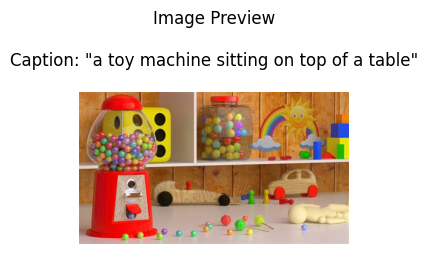

VQA Results:
❓ Answering: 'What color are these shoes?'
Answer: 'red'
  Q: What color are these shoes?
  A: red

❓ Answering: 'What brand are these shoes?'
Answer: 'crocks'
  Q: What brand are these shoes?
  A: crocks

❓ Answering: 'Are these sneakers or dress shoes?'
Answer: 'dress shoes'
  Q: Are these sneakers or dress shoes?
  A: dress shoes



In [62]:
# TEST: Visual Question Answering
print("❓ TESTING: Visual Question Answering...")
test_questions = [
    "What color are these shoes?",
    "What brand are these shoes?",
    "Are these sneakers or dress shoes?"
]

print("🔍 REAL USE CASE 5 images one per category: QA product image...")
#Building the result dataset
idx = 1
#captioned_images = test_images.copy() we use the same dataset of captioned images
for idx, item in enumerate(captioned_images, start=1):
    print(f"Image#:{idx}: Auto Cat:{item.classified_category}: Desc {item.caption}")
    image = load_image_from_url(item.url)
    visualize_caption_result(image, caption, "Image Preview", 3)
    print("VQA Results:")
    for question in test_questions:
      answer = ask_about_product(image, question)
      print(f"  Q: {question}")
      print(f"  A: {answer}")
      print()



### Get Category Questions and Answers

In [56]:
def get_category_questions(category: str) -> List[str]:
    """
    Generate relevant questions based on product category

    Args:
        category (str): Product category (e.g., "shoes", "clothing")

    Returns:
        List[str]: List of relevant questions for the category

    TODO: Create category-specific questions for better product analysis

    EXAMPLE INPUT: "shoes"
    EXAMPLE OUTPUT: [
        "What color are these shoes?",
        "What type of shoes are these?",
        "What brand are these shoes?",
        "What material are these shoes made of?"
    ]
    """

    # TODO: Create a mapping of categories to relevant questions
    # Categories to support: clothing, shoes, electronics, furniture, books, toys

    question_map = {
        "shoes": [
            "What color are these shoes?",
            "What type of shoes are these?",
            "What brand are these shoes?",
            "What material are these shoes made of?"
        ],
        "clothing": [
            "What type of clothing is this?",
            "What color is this clothing item?",
            "Is this item meant for men, women, or children?",
            "Does the clothing have any visible logos or patterns?"
        ],
        "electronics": [
            "What electronic device is this?",
            "What brand is this device?",
            "What color is the device?",
            "Is the screen turned on or off?"
        ],
        "furniture": [
            "What piece of furniture is shown?",
            "What material is this furniture made of?",
            "What color is the furniture?",
            "Is this furniture designed for indoor or outdoor use?"
        ],
        "toys": [
            "What kind of toy is this?",
            "What color is the toy?",
            "Is this toy suitable for young children?",
            "Does the toy resemble a character or animal?"
        ]
    }


    # TODO: Return questions for the category, or default questions if category not found
    return question_map.get(category, [
        "What color is this?",
        "What type of item is this?",
        "What is this made of?"
    ])

# TEST: Category questions
print("📋 TESTING: Category-specific questions...")
test_categories = ["shoes", "clothing", "electronics", "furniture","toys"]

for category in test_categories:
    questions = get_category_questions(category)
    print(f"{category.title()} Questions:")
    for q in questions:
        print(f"  - {q}")
    print()


📋 TESTING: Category-specific questions...
Shoes Questions:
  - What color are these shoes?
  - What type of shoes are these?
  - What brand are these shoes?
  - What material are these shoes made of?

Clothing Questions:
  - What type of clothing is this?
  - What color is this clothing item?
  - Is this item meant for men, women, or children?
  - Does the clothing have any visible logos or patterns?

Electronics Questions:
  - What electronic device is this?
  - What brand is this device?
  - What color is the device?
  - Is the screen turned on or off?

Furniture Questions:
  - What piece of furniture is shown?
  - What material is this furniture made of?
  - What color is the furniture?
  - Is this furniture designed for indoor or outdoor use?

Toys Questions:
  - What kind of toy is this?
  - What color is the toy?
  - Is this toy suitable for young children?
  - Does the toy resemble a character or animal?



---

### Product Analyzer

In [57]:
def analyze_product(image_url_or_pil: Union[str, Image.Image]) -> Dict:
    """
    Main function to analyze a product image and generate complete metadata

    Args:
        image_url_or_pil (Union[str, Image.Image]): Image URL or PIL Image

    Returns:
        Dict: Complete product analysis including category, description, and attributes

    TODO: Implement the complete product analysis pipeline

    PIPELINE STEPS:
    1. Load image (if URL provided)
    2. Classify product category using CLIP
    3. Generate product description using BLIP captioning
    4. Ask category-specific questions using BLIP VQA
    5. Compile and return results

    EXAMPLE INPUT: "https://images.unsplash.com/photo-1542291026-7eec264c27ff"
    EXAMPLE OUTPUT: {
        "category": {"name": "shoes", "confidence": 0.8945},
        "description": "a pair of red nike sneakers on a white background",
        "attributes": {
            "What color are these shoes?": "red",
            "What type of shoes are these?": "sneakers",
            "What brand are these shoes?": "nike"
        },
        "status": "success"
    }
    """
    print("🚀 Starting product analysis...")
    print("=" * 50)

    try:
        # TODO: Step 1 - Load image if URL provided
        if isinstance(image_url_or_pil, str):
            image = load_image_from_url(image_url_or_pil)
            if image is None:
                return {"error": "Failed to load image", "status": "failed"}
        else:
            image = image_url_or_pil

        # TODO: Step 2 - Classify product category
        product_categories = ["clothing", "shoes", "electronics", "furniture", "books", "toys"]
        classification_results = classify_product_image(image, product_categories)
        top_category = classification_results[0]

        # TODO: Step 3 - Generate product description
        description = generate_product_caption(image)

        # TODO: Step 4 - Get category-specific questions and ask them
        category = top_category['label']
        questions = get_category_questions(category)
        qa_results = {}
        for question in questions:
            answer = ask_about_product(image, question)
            qa_results[question] = answer

        # TODO: Step 5 - Compile results
        result = {
            "category": {"name": category, "confidence": top_category['score']},
            "description": description,
            "attributes": qa_results,
            "status": "success"
        }

        # DUMMY IMPLEMENTATION (Remove this when implementing)
        # result = {
        #     "category": {"name": "shoes", "confidence": 0.8945},
        #     "description": "a pair of red sneakers on a white background",
        #     "attributes": {
        #         "What color are these shoes?": "red",
        #         "What type of shoes are these?": "sneakers"
        #     },
        #     "status": "success"
        # }
        # print("⚠️ DUMMY: Returning fake analysis results")

        print("\n✅ Product analysis complete!")
        return result

    except Exception as e:
        print(f"❌ Error during processing: {e}")
        return {"error": str(e), "status": "failed"}

# TEST: Complete product analysis
print("🚀 TESTING: Complete product analysis pipeline...")
analysis_result = analyze_product(sample_url)
print("Complete Analysis Result:")
print(analysis_result)
print()

🚀 TESTING: Complete product analysis pipeline...
🚀 Starting product analysis...
⚠️ Loading image from https://images.unsplash.com/photo-1542291026-7eec264c27ff
🔍 Classifying product category...


Device set to use cuda:0


📝 Generating image caption...
DEBUG: Processing Image: torch.Size([1, 3, 384, 384]) (batch size, channels, height, width)
❓ Answering: 'What color are these shoes?'
Answer: 'red'
❓ Answering: 'What type of shoes are these?'
Answer: 'nike'
❓ Answering: 'What brand are these shoes?'
Answer: 'nike'
❓ Answering: 'What material are these shoes made of?'
Answer: 'fabric'

✅ Product analysis complete!
Complete Analysis Result:
{'category': {'name': 'shoes', 'confidence': 0.9677734375}, 'description': 'a red and white shoe on a red background', 'attributes': {'What color are these shoes?': 'red', 'What type of shoes are these?': 'nike', 'What brand are these shoes?': 'nike', 'What material are these shoes made of?': 'fabric'}, 'status': 'success'}



---

### Creating a Product Catalog using LLM inference

In [63]:
import requests
from typing import Dict, Optional

class SimpleLLMResponder:
    def __init__(
        self,
        api_url: str = "https://router.huggingface.co/together/v1/chat/completions",
        model: str = "mistralai/Mistral-7B-Instruct-v0.3",
        max_tokens: int = 512
    ):
        self.api_url = api_url
        self.model = model
        self.max_tokens = max_tokens

    def ask(self, prompt: str, api_key: str) -> Optional[str]:
        headers = {"Authorization": f"Bearer {api_key}"}
        payload = {
            "model": self.model,
            "max_tokens": self.max_tokens,
            "messages": [{"role": "user", "content": prompt}]
        }

        try:
            response = requests.post(self.api_url, headers=headers, json=payload, timeout=30)
            if response.status_code == 200:
                data = response.json()
                return data["choices"][0]["message"]["content"]
            else:
                print(f"❌ API Error {response.status_code}: {response.text}")
        except Exception as e:
            print(f"❌ Request failed: {e}")

        return None


In [64]:
def generate_final_product_description(metadata: Dict, api_key: str) -> str:
    """
    Generate a clean e-commerce-style product description using LLM output.
    """
    category = metadata.get("category", {}).get("name", "unknown")
    description = metadata.get("description", "")
    attributes = metadata.get("attributes", {})

    attr_text = "\n".join([f"- {q}: {a}" for q, a in attributes.items()])

    prompt = f"""I have the following information about a product image:

- Category: {category}
- Initial Caption: {description}
- Detected Attributes:
{attr_text}

Please write a vivid and engaging product description suitable for an online catalog. Be concise and helpful for shoppers."""

    llm = SimpleLLMResponder()
    response = llm.ask(prompt, api_key=api_key)

    return response or "[LLM response failed]"


In [ ]:
# TEST The LLM Generation
product_metedata = analyze_product(image)

### Product Catalog Generator Pipeline

Image as input
Image and Product Description as Ouput

In [71]:
# Visualization Function
def visualize_product_cart(products: List[Dict], preview_size: int = 2):
    """
    Display a list of product results in a simple cart layout.

    Args:
        products (List[Dict]): List of dicts, each with keys:
            - 'image': PIL.Image.Image
            - 'final_description': str
        preview_size (int): Width of image display area in inches
    """
    for product in products:
        image = product.get("image")
        description = product.get("final_description", "No description provided.")

        fig, ax = plt.subplots(1, 2, figsize=(preview_size + 4, preview_size))
        ax[0].imshow(image)
        ax[0].axis("off")

        ax[1].text(0, 0.5, description, fontsize=11, wrap=True, verticalalignment='center')
        ax[1].axis("off")

        plt.tight_layout()
        plt.show()


In [72]:
# PROD: Product Catalog Generator Pipeline
# Populates   catalog_images with image and descrption

print("🔍 REAL USE CASE 5 images one per category")
#Building the product dataset
idx = 1
catalog_images = test_images.copy()
for idx, item in enumerate(catalog_images, start=1):
    print(f"Image#:{idx}: Auto Cat:{item.classified_category}: Cap {item.caption}")
    image = load_image_from_url(item.url)
    image_meta = analyze_product(image)
    description = generate_final_product_description(image_meta, userdata.get('HF_TOKEN'))
    item.image = image
    item.description = description

🔍 REAL USE CASE 5 images one per category
Image#:1: Auto Cat:None: Cap None
⚠️ Loading image from https://tse3.mm.bing.net/th?id=OIP.Y1ZCZNBuM6LyX9xNy3_jyAHaHa&pid=Api
🚀 Starting product analysis...
🔍 Classifying product category...


Device set to use cuda:0


📝 Generating image caption...
DEBUG: Processing Image: torch.Size([1, 3, 384, 384]) (batch size, channels, height, width)
❓ Answering: 'What color are these shoes?'
Answer: 'green and white'
❓ Answering: 'What type of shoes are these?'
Answer: 'sneakers'
❓ Answering: 'What brand are these shoes?'
Answer: 'nike'
❓ Answering: 'What material are these shoes made of?'
Answer: 'leather'

✅ Product analysis complete!
Image#:2: Auto Cat:None: Cap None
⚠️ Loading image from https://tse1.mm.bing.net/th?id=OIP.q4gNcjltZtqufiyg0XL0cwHaE8&pid=Api
🚀 Starting product analysis...
🔍 Classifying product category...


Device set to use cuda:0


📝 Generating image caption...
DEBUG: Processing Image: torch.Size([1, 3, 384, 384]) (batch size, channels, height, width)
❓ Answering: 'What color are these shoes?'
Answer: 'green'
❓ Answering: 'What type of shoes are these?'
Answer: 'running shoes'
❓ Answering: 'What brand are these shoes?'
Answer: 'asics'
❓ Answering: 'What material are these shoes made of?'
Answer: 'nylon'

✅ Product analysis complete!
Image#:3: Auto Cat:None: Cap None
⚠️ Loading image from https://tse4.mm.bing.net/th?id=OIP.w18CXqXfi-8C-d1q89_ycgHaE8&pid=Api
🚀 Starting product analysis...
🔍 Classifying product category...


...

📝 Generating image caption...
DEBUG: Processing Image: torch.Size([1, 3, 384, 384]) (batch size, channels, height, width)
❓ Answering: 'What piece of furniture is shown?'
Answer: 'couch'
❓ Answering: 'What material is this furniture made of?'
Answer: 'leather'
❓ Answering: 'What color is the furniture?'
Answer: 'brown'
❓ Answering: 'Is this furniture designed for indoor or outdoor use?'
Answer: 'indoor'

✅ Product analysis complete!
Image#:5: Auto Cat:None: Cap None
⚠️ Loading image from https://tse2.mm.bing.net/th?id=OIP.jI3l55g0qfpmktGJiBmZ5wHaE8&pid=Api
🚀 Starting product analysis...
🔍 Classifying product category...


Device set to use cuda:0


📝 Generating image caption...
DEBUG: Processing Image: torch.Size([1, 3, 384, 384]) (batch size, channels, height, width)
❓ Answering: 'What color is this?'
Answer: 'blue'
❓ Answering: 'What type of item is this?'
Answer: 'books'
❓ Answering: 'What is this made of?'
Answer: 'books'

✅ Product analysis complete!
Image#:6: Auto Cat:None: Cap None
⚠️ Loading image from https://tse1.mm.bing.net/th/id/OIP.yhbFumPhqRwbTaKsIBd90AHaEK?pid=Api
🚀 Starting product analysis...
🔍 Classifying product category...


Device set to use cuda:0


📝 Generating image caption...
DEBUG: Processing Image: torch.Size([1, 3, 384, 384]) (batch size, channels, height, width)
❓ Answering: 'What kind of toy is this?'
Answer: 'candy'
❓ Answering: 'What color is the toy?'
Answer: 'red'
❓ Answering: 'Is this toy suitable for young children?'
Answer: 'yes'
❓ Answering: 'Does the toy resemble a character or animal?'
Answer: 'animal'

✅ Product analysis complete!


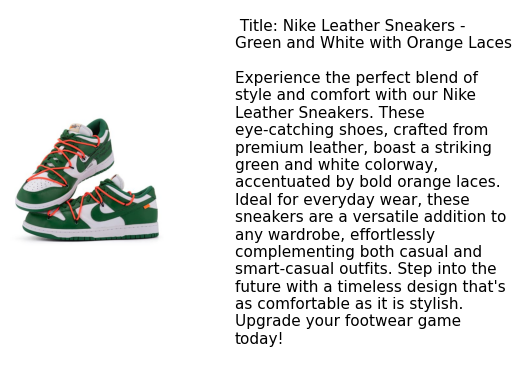

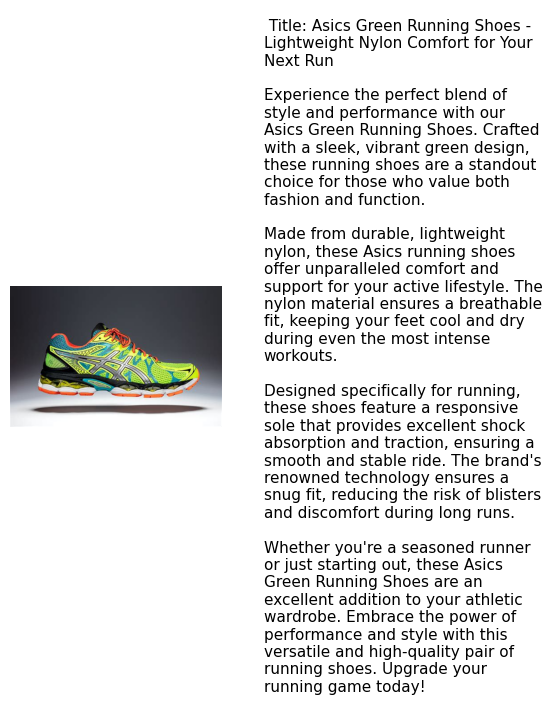

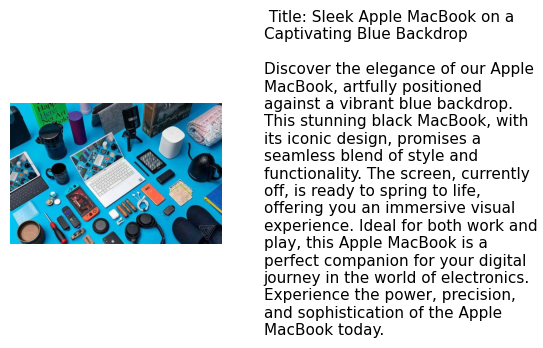

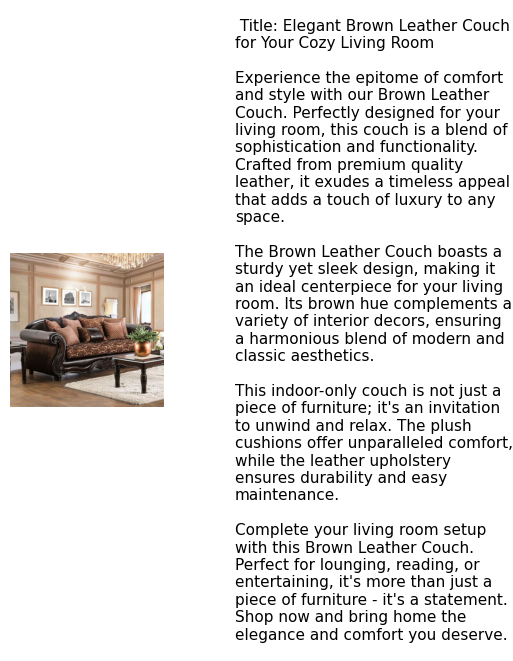

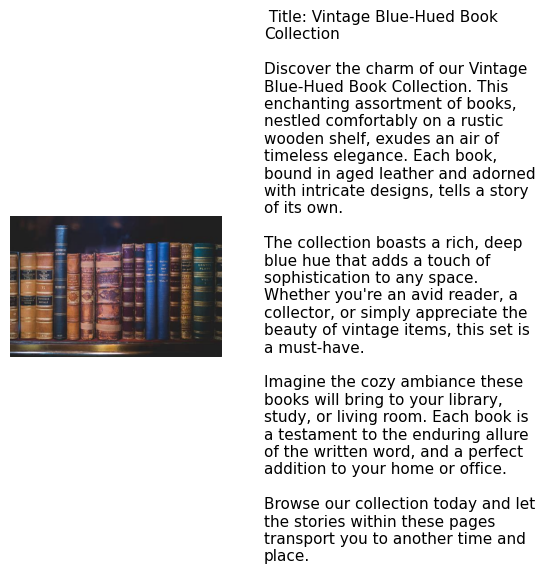

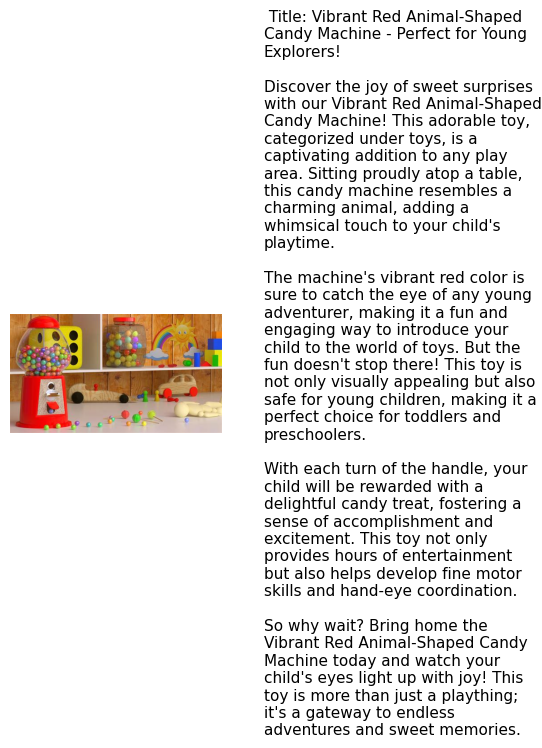

In [73]:
products = []
for ti in catalog_images:
    if ti.image:  # skip if image is None
        products.append({
            "image": ti.image,
            "final_description": ti.description or "No description available."
        })
visualize_product_cart(products)